# Holographic Rendering of a Helix — Computer-Generated Holography is Gerchberg-Saxton

A hologram stores a 3-D scene in a 2-D **phase** pattern: illuminate the right phase mask and the
object reappears in the diffracted light. Computing that mask — **computer-generated holography
(CGH)** — is *exactly* the phase-retrieval problem this repo is built on: find a phase $\phi$ such
that the far-field intensity $|\mathcal F\{e^{i\phi}\}|^2$ equals a target image.

Two ways to solve it, both here:
1. **Gerchberg-Saxton** — alternate between the target amplitude (far field) and the phase-only
   constraint (SLM plane). The same loop as `gs_core.py`'s TD-GS.
2. **Torch autograd** — make the FFT pipeline differentiable and descend on the phase mask directly
   (GPU). Differentiable optics: the modern, ML-native route.

Plus a 3-D render of the double helix that ties back to Photo 51. Runs on the **py312 (torch)** kernel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
dev = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", dev)

torch 2.11.0+cu128 | device: cuda


## §1 The double helix in 3-D

Two strands $\mathbf r_{1,2}(\theta)=(R\cos\theta,\,R\sin\theta,\,p\theta)$ offset in phase, with
base-pair rungs between them — the object whose 2-D shadow gave the Photo 51 "X".

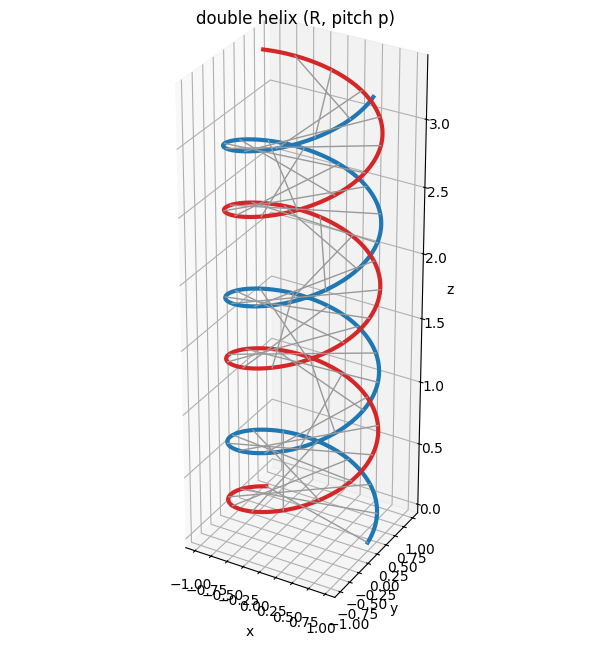

In [2]:
theta = np.linspace(0, 6*np.pi, 400)
R, pitch, offset = 1.0, 0.18, np.deg2rad(150)
x1, y1, z1 = R*np.cos(theta), R*np.sin(theta), pitch*theta
x2, y2, z2 = R*np.cos(theta+offset), R*np.sin(theta+offset), pitch*theta

fig = plt.figure(figsize=(6, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(x1, y1, z1, color="C0", lw=3); ax.plot(x2, y2, z2, color="C3", lw=3)
for i in range(0, len(theta), 10):     # base-pair rungs
    ax.plot([x1[i], x2[i]], [y1[i], y2[i]], [z1[i], z2[i]], color="0.6", lw=1)
ax.set_title("double helix (R, pitch p)"); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_box_aspect((1, 1, 3)); plt.tight_layout(); plt.show()

## §2 The hologram problem

Goal: a **phase-only** field $E=e^{i\phi}$ at the modulator whose far-field (Fourier) intensity
reproduces a target image $T$. Phase only — the amplitude is fixed at 1, exactly the
constant-envelope constraint from the QPSK TD-GS. We pick a simple target (a ring and a dot).

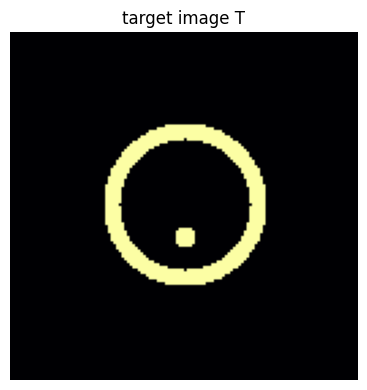

In [3]:
N = 128
yy, xx = np.mgrid[0:N, 0:N]; cy = cx = N//2
r = np.sqrt((yy-cy)**2 + (xx-cx)**2)
T = np.zeros((N, N))
T[(r > 24) & (r < 30)] = 1.0
T[(yy-cy+12)**2 + (xx-cx)**2 < 16] = 1.0
T = T / T.sum()
plt.figure(figsize=(4, 4)); plt.imshow(T, cmap="inferno", origin="lower")
plt.title("target image T"); plt.axis("off"); plt.tight_layout(); plt.show()

def corr(a, b):
    a = a - a.mean(); b = b - b.mean()
    return float((a*b).sum() / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12))

## §3 Gerchberg-Saxton CGH (the classic)

Alternate: far field $\to$ enforce $|F|=\sqrt T$ (keep phase); back-transform $\to$ enforce unit
amplitude (keep phase). Sixty passes and the phase mask reconstructs the target.

GS CGH correlation with target: 0.990


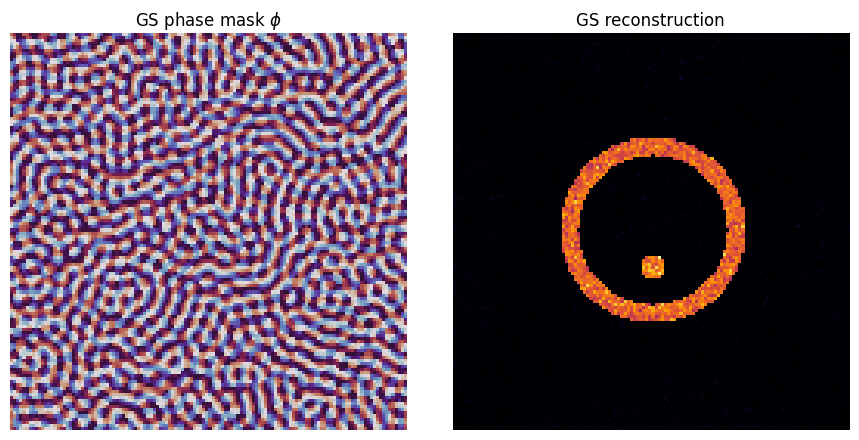

In [4]:
rng = np.random.default_rng(0)
phi = rng.uniform(-np.pi, np.pi, (N, N))
target_amp = np.sqrt(T)
for _ in range(60):
    far = np.fft.fftshift(np.fft.fft2(np.exp(1j*phi)))
    far = target_amp * np.exp(1j*np.angle(far))
    phi = np.angle(np.fft.ifft2(np.fft.ifftshift(far)))
recon_gs = np.abs(np.fft.fftshift(np.fft.fft2(np.exp(1j*phi))))**2
recon_gs /= recon_gs.sum()
print(f"GS CGH correlation with target: {corr(recon_gs, T):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 4.4))
ax[0].imshow(phi, cmap="twilight", origin="lower"); ax[0].set_title("GS phase mask $\\phi$"); ax[0].axis("off")
ax[1].imshow(recon_gs, cmap="inferno", origin="lower"); ax[1].set_title("GS reconstruction"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## §4 Torch autograd CGH (differentiable optics, on GPU)

Now make the whole forward model — phase mask $\to$ field $\to$ FFT $\to$ intensity — differentiable,
and let Adam descend on $\phi$. The loss is **negative cosine similarity** to the target (plain MSE
has a trivial uniform-spread minimum for sparse targets — a real trap worth knowing). Backprop runs
through the complex FFT on the GPU.

torch CGH correlation with target: 0.999  (device cuda)


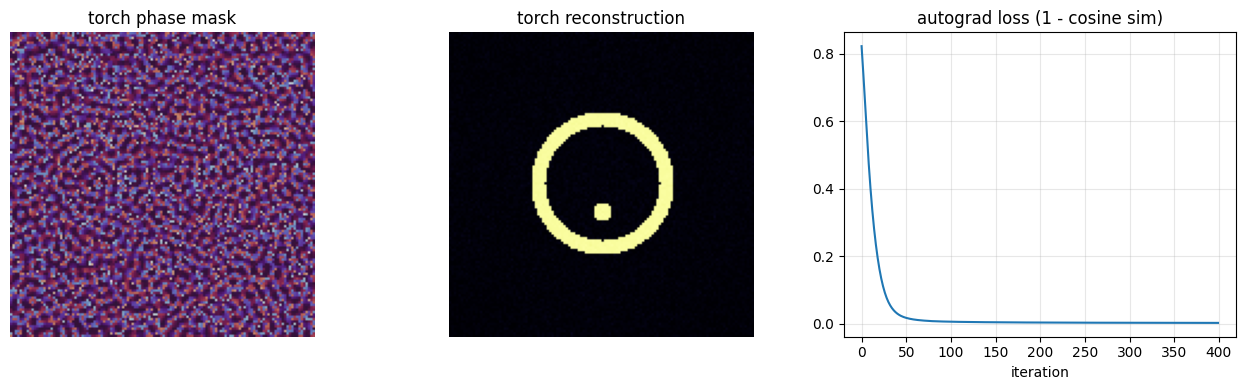

In [5]:
Tt = torch.tensor(T, dtype=torch.float32, device=dev)
Tf = Tt.flatten()
phi_t = torch.tensor(rng.uniform(-np.pi, np.pi, (N, N)), dtype=torch.float32,
                     device=dev, requires_grad=True)
opt = torch.optim.Adam([phi_t], lr=0.05)
losses = []
for it in range(400):
    opt.zero_grad()
    field = torch.exp(1j * phi_t.to(torch.complex64))
    recon = torch.fft.fftshift(torch.fft.fft2(field)).abs()**2
    recon = recon / recon.sum()
    rf = recon.flatten()
    loss = 1 - (rf @ Tf) / (rf.norm() * Tf.norm() + 1e-12)
    loss.backward(); opt.step(); losses.append(loss.item())
recon_t = recon.detach().cpu().numpy()
print(f"torch CGH correlation with target: {corr(recon_t, T):.3f}  (device {dev})")

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(phi_t.detach().cpu().numpy(), cmap="twilight", origin="lower")
ax[0].set_title("torch phase mask"); ax[0].axis("off")
ax[1].imshow(recon_t, cmap="inferno", origin="lower"); ax[1].set_title("torch reconstruction"); ax[1].axis("off")
ax[2].plot(losses); ax[2].set_title("autograd loss (1 - cosine sim)"); ax[2].set_xlabel("iteration")
ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §5 The connections

- **CGH = Gerchberg-Saxton = phase retrieval.** §3 is the same alternating-projection loop as the
  TD-GS in `gs_core.py` — here the two "planes" are the SLM and its Fourier far field, with a
  phase-only (unit-amplitude) constraint, exactly the `unit_amplitude=True` path used for QPSK.
- **Differentiable optics → ML.** §4 turns the optical forward model into a torch graph and trains
  the phase mask by gradient descent. Replace the fixed FFT with learned spectral weights and you
  have the FNO in `gs_fno.py`; this is the bridge from classical phase retrieval to neural phase
  recovery (the unsupervised/Deep-Dispersion-Prior direction).
- **Holography is phase encoding.** A hologram literally stores a scene in phase — the quantity that
  square-law detectors throw away and that this whole project exists to recover. Photo 51 read phase
  out of a helix; CGH writes a scene into phase; TD-GS recovers phase from dispersion. Same currency.

Module-free notebook (uses numpy + torch directly); verified in `scripts/smoke_holography.py`
(GS 0.99, torch 0.999 on CUDA). Runs on the py312 kernel because torch is 3.12-only here.